<a href="https://colab.research.google.com/github/akriti404/Deep-Learning-Lab/blob/main/lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            # Latent representation
            nn.Linear(128, 32),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Flatten image
        x = x.view(x.size(0), -1)

        # Encoder
        latent = self.encoder(x)

        # Decoder
        reconstruction = self.decoder(latent)

        return reconstruction, latent

model = SparseAutoencoder().to(device)

print(model)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


lambda_sparse = 0.001


num_epochs = 20

for epoch in range(num_epochs):

    model.train()

    total_loss = 0
    total_reconstruction_loss = 0
    total_sparse_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        # Forward pass
        reconstructed, latent = model(images)
        # Recon  struction loss
        reconstruction_loss = criterion(
            reconstructed,
            images.view(images.size(0), -1)
        )

        # L1 Sparsity loss
        sparsity_loss = torch.mean(
            torch.abs(latent)
        )

        # Total loss
        loss = (
            reconstruction_loss
            + lambda_sparse * sparsity_loss
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
        total_loss += loss.item()
        total_reconstruction_loss += reconstruction_loss.item()
        total_sparse_loss += sparsity_loss.item()

    # Average losses
    avg_loss = total_loss / len(train_loader)
    avg_reconstruction = (
        total_reconstruction_loss / len(train_loader)
    )
    avg_sparse = (
        total_sparse_loss / len(train_loader)
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Total Loss: {avg_loss:.6f} | "
        f"Reconstruction: {avg_reconstruction:.6f} | "
        f"Sparsity: {avg_sparse:.6f}"
    )

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 15.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 456kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.23MB/s]


SparseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
Epoch [1/20] Total Loss: 0.056140 | Reconstruction: 0.055350 | Sparsity: 0.790144
Epoch [2/20] Total Loss: 0.027598 | Reconstruction: 0.026633 | Sparsity: 0.964829
Epoch [3/20] Total Loss: 0.021662 | Reconstruction: 0.020629 | Sparsity: 1.033183
Epoch [4/20] Total Loss: 0.018563 | Reconstruction: 0.017537 | Sparsity: 1.026125
Epoch [5/20] Total Loss: 0.016624 | Reconstruction: 0.015624 | Sparsity: 1.000960
Epoch [6/20] Total Loss: 0.015326 | Recons

Using device: cuda
UndercompleteAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

--- Starting Training ---
Epoch [1/10] - Reconstruction Loss: 0.052284
Epoch [2/10] - Reconstruction Loss: 0.024458
Epoch [3/10] - Reconstruction Loss: 0.018780
Epoch [4/10] - Reconstruction Loss: 0.016382
Epoch [5/10] - Reconstruction Loss: 0.014844
Epoch [6/10] - Reconstruction Loss: 0.013873
Epoch [7/10] - Reconstruction Loss: 0.013271
Epoch [8/10] - Reconstruction Loss: 0.012818
Epoch [9/10] - Reconstruction Loss: 0.012460
Epoch [10/10] - Reconstruction Loss: 0.012132


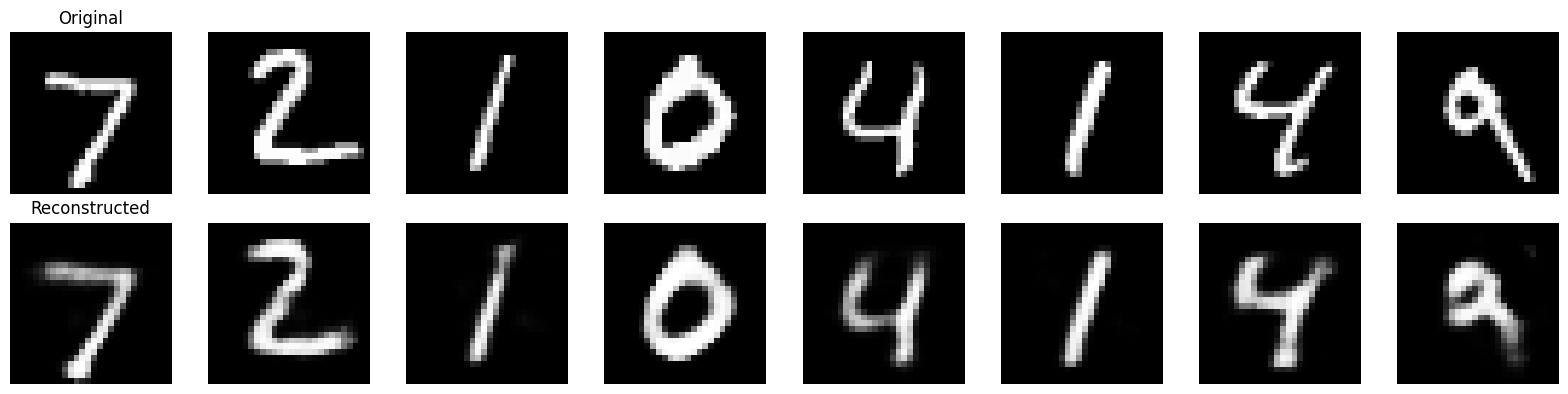

In [2]:
# ===================================================================
# PyTorch Implementation: Undercomplete Autoencoder
# Dataset: MNIST (Handwritten Digits)
# ===================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS = 10
INPUT_DIM = 28 * 28  # 784 pixels
LATENT_DIM = 32      # Undercomplete Bottleneck (784 -> 32)

transform = transforms.Compose([
    transforms.ToTensor(), # Converts image to Tensor with values in range [0.0, 1.0]
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class UndercompleteAutoencoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super(UndercompleteAutoencoder, self).__init__()

        # Encoder: 784 -> 128 -> 32 (Undercomplete Bottleneck)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )

        # Decoder: 32 -> 128 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()  # Reconstructs pixel values to [0, 1] range
        )

    def forward(self, x):
        # Flatten input: (batch_size, 1, 28, 28) -> (batch_size, 784)
        x_flat = x.view(x.size(0), -1)

        # Encode to low-dimensional latent space
        latent_code = self.encoder(x_flat)

        # Decode back to original input dimension
        reconstruction = self.decoder(latent_code)

        # Reshape to original image format: (batch_size, 1, 28, 28)
        reconstruction = reconstruction.view(x.size(0), 1, 28, 28)
        return reconstruction, latent_code

# Instantiate Model, Loss Function, and Optimizer
model = UndercompleteAutoencoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

print("\n--- Starting Training ---")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        # Forward pass
        reconstructed, _ = model(images)
        loss = criterion(reconstructed, images)

        # Backward pass & Optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch}/{EPOCHS}] - Reconstruction Loss: {epoch_loss:.6f}")

# ---------------------------------------------------------------------
# Visualization: Original vs. Reconstructed Images
# ---------------------------------------------------------------------
model.eval()
with torch.no_grad():
    data_iter = iter(test_loader)
    images, _ = next(data_iter)
    images = images.to(device)

    reconstructed, _ = model(images)

    # Move back to CPU for plotting
    images = images.cpu()
    reconstructed = reconstructed.cpu()

# Plot first 8 images
fig, axes = plt.subplots(nrows=2, ncols=8, figsize=(16, 4))

for i in range(8):
    # Top Row: Original
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Original", fontsize=12)

    # Bottom Row: Reconstructed
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("Reconstructed", fontsize=12)

plt.tight_layout()
plt.show()